# ICOtest Report Analysis

This notebook loads and analyzes all JSON test reports from the `reports/` directory.

**Features:**
- Load all test reports into a tabular DataFrame
- Store time series data separately for efficient analysis
- Interactive filtering by device and date range
- Visualize power usage trends and device comparisons
- Access raw time series data for detailed inspection

## 1. Setup - Import Libraries and Define Helpers

In [14]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [16]:
# Define helper functions

class TestReportAnalyzer:
    """Manages loading and storing test report data"""
    
    def __init__(self, reports_dir='../reports'):
        self.reports_dir = Path(reports_dir)
        self.df = None
        self.time_series_store = {}  # {(device_name, timestamp, test_name): {array_name: array_data}}
        self.report_files = []
    
    def find_reports(self):
        """Find all JSON report files"""
        hardware_test_files = glob.glob(str(self.reports_dir / 'hardware_test_*.json'))
        icotronic_files = glob.glob(str(self.reports_dir / 'ICOtronic_*.json'))
        self.report_files = sorted(hardware_test_files + icotronic_files)
        return len(self.report_files)
    
    def load_all_reports(self):
        """Load and parse all reports"""
        records = []
        
        for report_file in self.report_files:
            try:
                with open(report_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # Extract device name from filename or report
                filename = Path(report_file).stem
                timestamp = data.get('created')
                timestamp_dt = datetime.fromtimestamp(timestamp) if timestamp else None
                
                # Process each test
                for test in data.get('tests', []):
                    record = self._extract_test_record(test, filename, timestamp_dt, data)
                    if record:
                        records.append(record)
                        
                        # Extract and store time series data
                        self._extract_time_series(test, filename, timestamp_dt)
            
            except Exception as e:
                print(f"⚠ Error loading {filename}: {e}")
        
        self.df = pd.DataFrame(records)
        return len(records)
    
    def _extract_test_record(self, test, filename, timestamp_dt, report_data):
        """Extract scalar data from a single test"""
        try:
            nodeid = test.get('nodeid', '')
            test_name = nodeid.split('::')[-1] if '::' in nodeid else nodeid
            
            record = {
                'filename': filename,
                'timestamp': timestamp_dt,
                'test_name': test_name,
                'outcome': test.get('outcome', 'unknown'),
                'nodeid': nodeid,
            }
            
            # Extract timing
            if 'call' in test and isinstance(test['call'], dict):
                record['duration_s'] = test['call'].get('duration', 0)
            
            # Extract metadata (scalar values only)
            if 'metadata' in test and isinstance(test['metadata'], dict):
                for key, value in test['metadata'].items():
                    # Only extract scalar values, skip arrays and complex types
                    if isinstance(value, dict) and 'value' in value:
                        # Structured measurement
                        scalar_value = value.get('value')
                        unit = value.get('unit', '')
                        record[f'{key}_value'] = scalar_value
                        if unit:
                            record[f'{key}_unit'] = unit
                    elif isinstance(value, (int, float)) and not isinstance(value, bool):
                        # Direct numeric value
                        record[f'{key}'] = value
                    elif isinstance(value, str):
                        # String metadata (like descriptions)
                        pass  # Skip string values for now
            
            # Add summary data from report level
            if 'summary' in report_data:
                record['summary_passed'] = report_data['summary'].get('passed')
                record['summary_failed'] = report_data['summary'].get('failed')
                record['summary_total'] = report_data['summary'].get('total')
            
            return record
        except Exception as e:
            print(f"Error extracting test record: {e}")
            return None
    
    def _extract_time_series(self, test, filename, timestamp_dt):
        """Extract and store time series arrays"""
        test_name = test.get('nodeid', '').split('::')[-1]
        metadata = test.get('metadata', {})
        
        time_series_data = {}
        has_series = False
        
        if metadata:
            for key, value in metadata.items():
                # Check if this is a time series array
                if isinstance(value, list) and len(value) > 10:
                    time_series_data[key] = np.array(value)
                    has_series = True
        
        if has_series:
            # Store with composite key
            store_key = (filename, timestamp_dt, test_name)
            self.time_series_store[store_key] = time_series_data
    
    def get_time_series(self, filename, timestamp_dt, test_name):
        """Retrieve time series data for a specific test"""
        key = (filename, timestamp_dt, test_name)
        return self.time_series_store.get(key, {})
    
    def has_time_series(self, filename, timestamp_dt, test_name):
        """Check if test has time series data"""
        key = (filename, timestamp_dt, test_name)
        return key in self.time_series_store

print("✓ TestReportAnalyzer class defined")

✓ TestReportAnalyzer class defined


## 2. Load and Parse Reports

In [17]:
# Initialize analyzer and load reports
analyzer = TestReportAnalyzer()

num_files = analyzer.find_reports()
print(f"Found {num_files} report files")

num_records = analyzer.load_all_reports()
print(f"\n✓ Loaded {num_records} test records")
print(f"✓ Found time series data in {len(analyzer.time_series_store)} tests")

# Display DataFrame info
print(f"\nDataFrame shape: {analyzer.df.shape}")
print(f"\nColumns: {list(analyzer.df.columns)}")

Found 79 report files

✓ Loaded 530 test records
✓ Found time series data in 75 tests

DataFrame shape: (530, 54)

Columns: ['filename', 'timestamp', 'test_name', 'outcome', 'nodeid', 'duration_s', 'summary_passed', 'summary_failed', 'summary_total', 'power_usage_disconnected_value', 'power_usage_disconnected_unit', 'power_usage_connected_value', 'power_usage_connected_unit', 'power_usage_streaming_value', 'power_usage_streaming_unit', 'self_test_voltage_abs_value', 'self_test_voltage_abs_unit', 'self_test_voltage_drift_value', 'self_test_voltage_drift_unit', 'acceleration_noise_snr_value', 'acceleration_noise_snr_unit', 'acceleration_mean_value', 'acceleration_mean_unit', 'acceleration_x_bias_value', 'acceleration_x_bias_unit', 'acceleration_x_snr_value', 'acceleration_x_snr_unit', 'acceleration_y_bias_value', 'acceleration_y_bias_unit', 'acceleration_y_snr_value', 'acceleration_y_snr_unit', 'acceleration_z_bias_value', 'acceleration_z_bias_unit', 'acceleration_z_snr_value', 'accelera

## 3. Data Inspection

In [18]:
# Display summary statistics
print("=" * 80)
print("DATA SUMMARY")
print("=" * 80)

print(f"\nDate Range: {analyzer.df['timestamp'].min()} to {analyzer.df['timestamp'].max()}")
print(f"\nUnique Devices: {analyzer.df['filename'].nunique()}")
print(f"Unique Tests: {analyzer.df['test_name'].nunique()}")
print(f"Total Records: {len(analyzer.df)}")

print(f"\nTest Outcomes:")
print(analyzer.df['outcome'].value_counts())

print(f"\nAvailable Measurement Fields:")
measurement_cols = [col for col in analyzer.df.columns if '_value' in col or '_unit' in col]
for col in sorted(set([c.replace('_value', '').replace('_unit', '') for c in measurement_cols])):
    print(f"  - {col}")

DATA SUMMARY

Date Range: 2026-02-10 16:26:03.600701 to 2026-03-23 12:11:45.759868

Unique Devices: 76
Unique Tests: 14
Total Records: 530

Test Outcomes:
outcome
passed    338
failed    122
error      70
Name: count, dtype: int64

Available Measurement Fields:
  - acceleration_mean
  - acceleration_noise_margin
  - acceleration_noise_snr
  - acceleration_vector_error
  - acceleration_x_bias
  - acceleration_x_snr
  - acceleration_y_bias
  - acceleration_y_snr
  - acceleration_z_bias
  - acceleration_z_snr
  - backpack_acc_torr_bias
  - backpack_acc_torr_snr
  - backpack_acc_x_bias
  - backpack_acc_x_snr
  - backpack_acc_y_bias
  - backpack_acc_y_snr
  - backpack_max_bias
  - backpack_max_noise
  - power_usage_connected
  - power_usage_disconnected
  - power_usage_streaming
  - self_test_voltage_abs
  - self_test_voltage_drift


In [11]:
# Show sample data
print("\nSample Records:")
display(analyzer.df.head(10))


Sample Records:


,filename,timestamp,test_name,outcome,nodeid,duration_s,summary_passed,summary_failed,summary_total,power_usage_disconnected_value,...,backpack_acc_x_snr_value,backpack_acc_x_snr_unit,backpack_acc_y_snr_value,backpack_acc_y_snr_unit,backpack_acc_torr_snr_value,backpack_acc_torr_snr_unit,backpack_max_bias_value,backpack_max_bias_unit,backpack_max_noise_value,backpack_max_noise_unit
0,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_connection,passed,icotest/test/test_sensor_node.py::test_connection,1.019786,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_supply_voltage,passed,icotest/test/test_sensor_node.py::test_supply_...,0.207558,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_power_usage_disconnected,passed,icotest/test/test_sensor_node.py::test_power_u...,1.616670,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_power_usage_connected,passed,icotest/test/test_sensor_node.py::test_power_u...,1.571474,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_power_usage_streaming,passed,icotest/test/test_sensor_node.py::test_power_u...,1.502060,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,hardware_test_2026-02-10_16-25,2026-02-10 16:26:03.600701,test_eeprom,passed,icotest/test/test_sensor_node.py::test_eeprom,2.713843,6.0,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,hardware_test_2026-03-17_11-27,2026-03-17 11:28:08.587116,test_firmware_upload,passed,icotest/test/test_sth_modify.py::test_firmware...,5.357758,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,hardware_test_2026-03-17_11-27,2026-03-17 11:28:08.587116,test_set_base64name,error,icotest/test/test_sth_modify.py::test_set_base...,NaN,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,hardware_test_2026-03-17_11-42,2026-03-17 11:42:39.608472,test_firmware_upload,passed,icotest/test/test_sth_modify.py::test_firmware...,5.338809,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,hardware_test_2026-03-17_11-42,2026-03-17 11:42:39.608472,test_set_base64name,error,icotest/test/test_sth_modify.py::test_set_base...,NaN,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Interactive Filtering

In [23]:
# Create device, test, and outcome selectors
device_selector = widgets.SelectMultiple(
    options=sorted(analyzer.df['filename'].unique()),
    value=(sorted(analyzer.df['filename'].unique())[0],),
    description='Devices:',
    rows=5
)

test_selector = widgets.SelectMultiple(
    options=sorted(analyzer.df['test_name'].unique()),
    description='Tests:',
    rows=5
)

outcome_selector = widgets.SelectMultiple(
    options=sorted(analyzer.df['outcome'].unique()),
    value=tuple(sorted(analyzer.df['outcome'].unique())),
    description='Outcomes:',
    rows=3
)

# Date range selection using text widgets
min_date = analyzer.df['timestamp'].min()
max_date = analyzer.df['timestamp'].max()

# Create date inputs
min_date_widget = widgets.Text(
    value=min_date.strftime('%Y-%m-%d %H:%M') if min_date else '',
    description='Min Date:',
    placeholder='YYYY-MM-DD HH:MM'
)

max_date_widget = widgets.Text(
    value=max_date.strftime('%Y-%m-%d %H:%M') if max_date else '',
    description='Max Date:',
    placeholder='YYYY-MM-DD HH:MM'
)

print("Interactive Filters:")
print("1. Select Devices:")
display(device_selector)

print("2. Select Tests (leave empty for all):")
display(test_selector)

print("3. Select Outcomes:")
display(outcome_selector)

print("4. Select Date Range:")
display(widgets.VBox([min_date_widget, max_date_widget]))

Interactive Filters:
1. Select Devices:


SelectMultiple(description='Devices:', index=(0,), options=('ICOtronic_BYUgAHwA_2026-03-17_11-28', 'ICOtronic_…

2. Select Tests (leave empty for all):


SelectMultiple(description='Tests:', options=('test_BaP_torr_accelleration', 'test_acceleration_3a_alt', 'test…

3. Select Outcomes:


SelectMultiple(description='Outcomes:', index=(0, 1, 2), options=('error', 'failed', 'passed'), rows=3, value=…

4. Select Date Range:


In [25]:
# Create filtered dataset based on selections

def get_filtered_data():
    """Apply all filters and return filtered DataFrame"""
    df_filtered = analyzer.df.copy()
    
    # Filter by device
    if device_selector.value:
        df_filtered = df_filtered[df_filtered['filename'].isin(device_selector.value)]
    
    # Filter by test
    if test_selector.value:
        df_filtered = df_filtered[df_filtered['test_name'].isin(test_selector.value)]
    
    # Filter by outcome
    if outcome_selector.value:
        df_filtered = df_filtered[df_filtered['outcome'].isin(outcome_selector.value)]
    
    # Filter by date range using text widgets
    try:
        min_date = datetime.strptime(min_date_widget.value, '%Y-%m-%d %H:%M') if min_date_widget.value else analyzer.df['timestamp'].min()
        max_date = datetime.strptime(max_date_widget.value, '%Y-%m-%d %H:%M') if max_date_widget.value else analyzer.df['timestamp'].max()
        
        df_filtered = df_filtered[
            (df_filtered['timestamp'] >= min_date) &
            (df_filtered['timestamp'] <= max_date)
        ]
    except ValueError as e:
        print("Invalid date format. Use YYYY-MM-DD HH:MM")
    
    return df_filtered.sort_values('timestamp')

# Display filtered data
df_filtered = get_filtered_data()
print("Filtered Data: {} records".format(len(df_filtered)))
display(df_filtered)

Filtered Data: 2 records


,filename,timestamp,test_name,outcome,nodeid,duration_s,summary_passed,summary_failed,summary_total,power_usage_disconnected_value,...,backpack_acc_x_snr_value,backpack_acc_x_snr_unit,backpack_acc_y_snr_value,backpack_acc_y_snr_unit,backpack_acc_torr_snr_value,backpack_acc_torr_snr_unit,backpack_max_bias_value,backpack_max_bias_unit,backpack_max_noise_value,backpack_max_noise_unit
0,ICOtronic_BYUgAHwA_2026-03-17_11-28,2026-03-17 11:28:30.516299,test_firmware_upload,passed,icotest/test/test_sth_modify.py::test_firmware...,5.393424,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ICOtronic_BYUgAHwA_2026-03-17_11-28,2026-03-17 11:28:30.516299,test_set_base64name,error,icotest/test/test_sth_modify.py::test_set_base...,0.391085,1.0,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Power Usage Analysis

Power-related measurements found: ['power_usage_disconnected_value', 'power_usage_connected_value', 'power_usage_streaming_value']



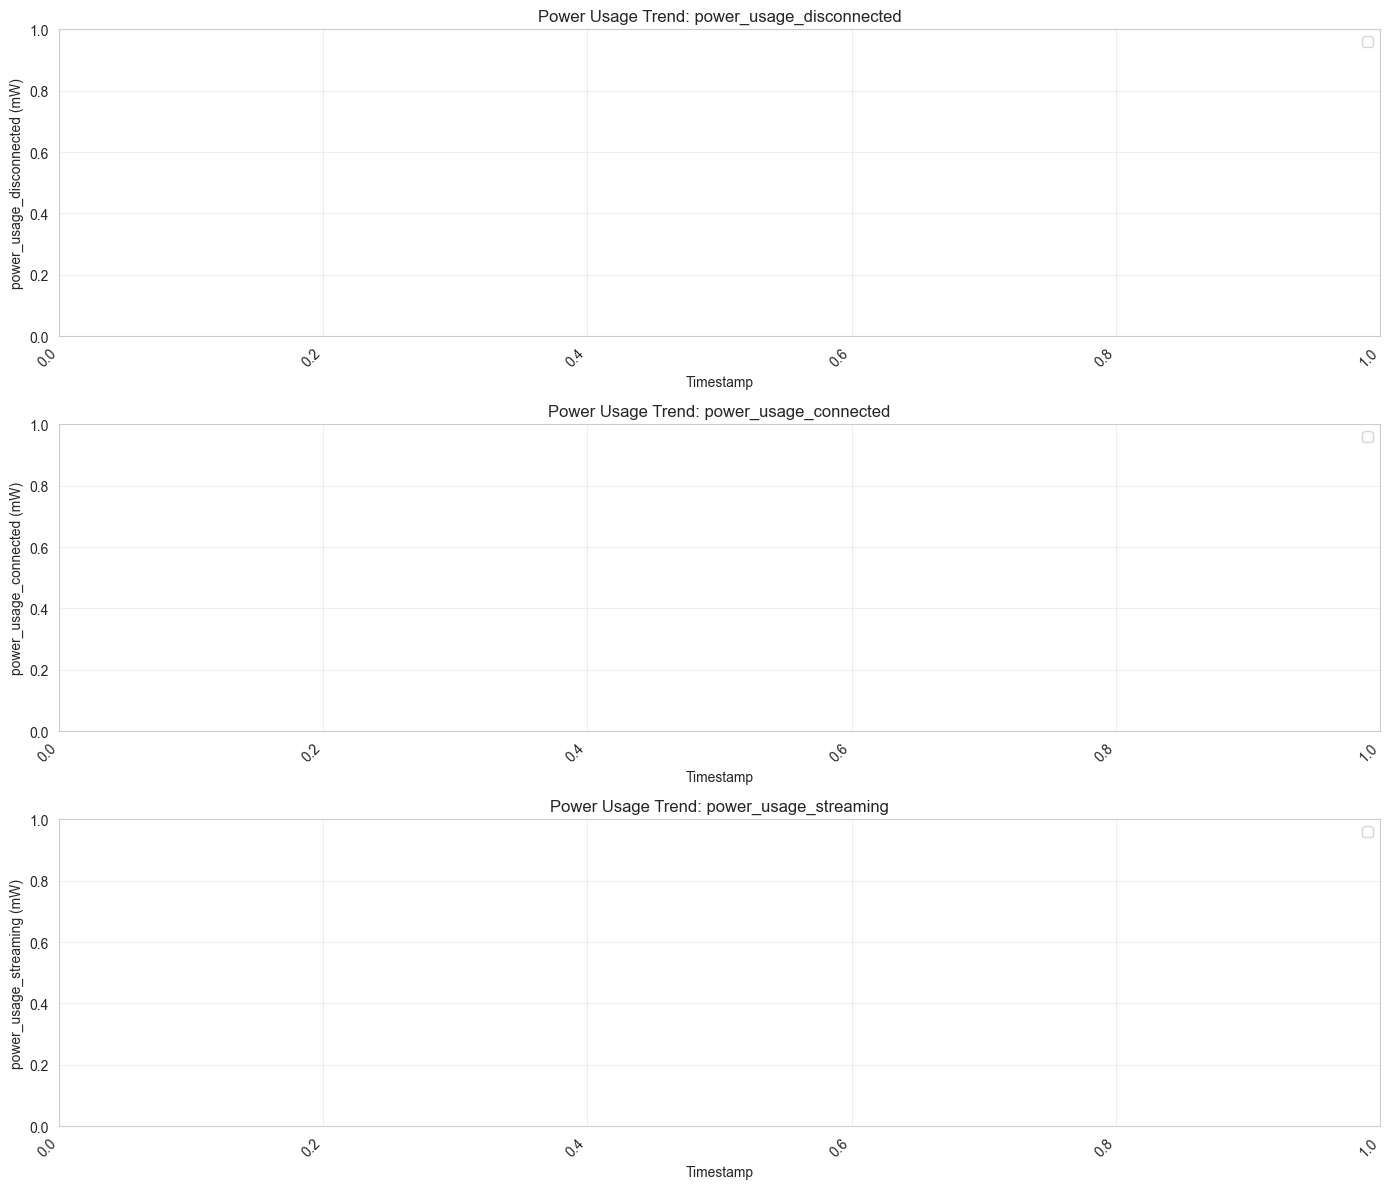

In [22]:
# Power usage trend analysis
df_power = get_filtered_data()

# Find columns related to power usage
power_cols = [col for col in df_power.columns if 'power' in col.lower() and '_value' in col]

if power_cols:
    print(f"Power-related measurements found: {power_cols}\n")
    
    fig, axes = plt.subplots(len(power_cols), 1, figsize=(14, 4 * len(power_cols)))
    if len(power_cols) == 1:
        axes = [axes]
    
    for ax, power_col in enumerate(power_cols):
        col_name = power_col.replace('_value', '')
        
        # Group by device and plot trends
        for device in df_power['filename'].unique():
            df_device = df_power[df_power['filename'] == device].sort_values('timestamp')
            
            # Get power values, skip NaN
            valid_data = df_device[["timestamp", power_col]].dropna()
            if len(valid_data) > 0:
                axes[ax].plot(valid_data['timestamp'], valid_data[power_col], 
                             marker='o', label=device, alpha=0.7)
        
        axes[ax].set_xlabel('Timestamp')
        axes[ax].set_ylabel(f"{col_name} (mW)")
        axes[ax].set_title(f"Power Usage Trend: {col_name}")
        axes[ax].legend()
        axes[ax].grid(True, alpha=0.3)
        plt.setp(axes[ax].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No power usage data found in current selection")

## 6. Device Comparison

In [ ]:
# Device comparison
df_comparison = get_filtered_data()

# Find numeric columns for comparison
numeric_cols = [col for col in df_comparison.columns if '_value' in col]

if numeric_cols and len(df_comparison['filename'].unique()) > 1:
    print(f"Available metrics for comparison: {[c.replace('_value', '') for c in numeric_cols]}\n")
    
    # Create comparison visualization for each metric
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = [axes]
    
    for ax, metric_col in enumerate(numeric_cols):
        metric_name = metric_col.replace('_value', '')
        
        # Prepare data for box plot
        plot_data = df_comparison[["filename", metric_col]].dropna()
        
        if len(plot_data) > 0:
            # Create box plot
            plot_data.boxplot(column=metric_col, by='filename', ax=axes[ax])
            axes[ax].set_title(f"Device Comparison: {metric_name}")
            axes[ax].set_xlabel('Device')
            axes[ax].set_ylabel(metric_name)
            plt.setp(axes[ax].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Need multiple devices and numeric metrics for comparison")

## 7. Time Series Deep Dive

In [ ]:
# Time series inspection and visualization

# Find tests with time series data
tests_with_series = []
for filename, timestamp, test_name in analyzer.time_series_store.keys():
    tests_with_series.append((filename, timestamp, test_name))

if tests_with_series:
    print(f"Found {len(tests_with_series)} tests with time series data\n")
    
    # Create selector for time series inspection
    series_options = [(f"{fn} | {tn}", (fn, ts, tn)) for fn, ts, tn in tests_with_series]
    
    series_selector = widgets.Dropdown(
        options=series_options,
        description='Select Test:'
    )
    display(series_selector)
    print("\nSelected test details:")

else:
    print("No time series data available in current reports")

In [ ]:
# Display time series for selected test
if tests_with_series:
    filename, timestamp, test_name = series_selector.value
    time_series_data = analyzer.get_time_series(filename, timestamp, test_name)
    
    print(f"Test: {test_name}")
    print(f"Device: {filename}")
    print(f"\nAvailable time series arrays:")
    
    for array_name, array_data in time_series_data.items():
        print(f"\n  {array_name}:")
        print(f"    Length: {len(array_data)}")
        print(f"    Mean: {np.mean(array_data):.2f}")
        print(f"    Std: {np.std(array_data):.2f}")
        print(f"    Min: {np.min(array_data):.2f}")
        print(f"    Max: {np.max(array_data):.2f}")
    
    # Plot time series
    num_series = len(time_series_data)
    fig, axes = plt.subplots(num_series, 1, figsize=(14, 4 * num_series))
    if num_series == 1:
        axes = [axes]
    
    for ax, (array_name, array_data) in enumerate(time_series_data.items()):
        axes[ax].plot(array_data, alpha=0.7)
        axes[ax].set_title(f"{array_name}")
        axes[ax].set_xlabel('Sample')
        axes[ax].set_ylabel('Value')
        axes[ax].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Raw DataFrame Access

In [ ]:
# Access filtered data for custom analysis

print("Use the following variables for custom analysis:")
print("\n  analyzer.df         - Full DataFrame with all records")
print("  get_filtered_data() - Function to get filtered DataFrame")
print("  analyzer.get_time_series(filename, timestamp, test_name) - Get time series data")

print("\n" + "="*80)
print("Current Filtered Data:")
print("="*80)

df_current = get_filtered_data()
print(f"\nShape: {df_current.shape}")
print(f"Columns: {list(df_current.columns)}")

# Show summary statistics
print("\nSummary Statistics:")
display(df_current.describe())

In [ ]:
# Display full filtered data
print("Full Filtered Data:")
display(df_current)

## 9. Helper Functions for Custom Analysis

In [ ]:
# Define utility functions for common analysis tasks

def get_test_by_name(test_name):
    """Get all records for a specific test name"""
    return analyzer.df[analyzer.df['test_name'] == test_name].sort_values('timestamp')

def get_device_data(filename):
    """Get all records for a specific device"""
    return analyzer.df[analyzer.df['filename'] == filename].sort_values('timestamp')

def compare_test_values(test_name, metric_col):
    """Compare metric values across devices for a specific test"""
    df_test = analyzer.df[analyzer.df['test_name'] == test_name]
    if metric_col in df_test.columns:
        return df_test[['filename', 'timestamp', metric_col]].dropna()
    else:
        print(f"Column '{metric_col}' not found")
        return None

def get_test_statistics(test_name):
    """Get statistics for a test across all runs"""
    df_test = analyzer.df[analyzer.df['test_name'] == test_name]
    
    stats = {
        'Total Runs': len(df_test),
        'Passed': (df_test['outcome'] == 'passed').sum(),
        'Failed': (df_test['outcome'] == 'failed').sum(),
        'Pass Rate': f"{(df_test['outcome'] == 'passed').sum() / len(df_test) * 100:.1f}%"
    }
    
    # Add numeric statistics
    numeric_cols = df_test.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if '_value' in col or '_duration' in col:
            stats[f"{col}_mean"] = df_test[col].mean()
            stats[f"{col}_std"] = df_test[col].std()
    
    return pd.Series(stats)

print("✓ Utility functions defined:")
print("  - get_test_by_name(test_name)")
print("  - get_device_data(filename)")
print("  - compare_test_values(test_name, metric_col)")
print("  - get_test_statistics(test_name)")

In [ ]:
# Example: Get statistics for a specific test

# Choose a test
example_test = analyzer.df['test_name'].value_counts().index[0]
print(f"Example: Statistics for '{example_test}'\n")

stats = get_test_statistics(example_test)
display(stats)